In [1]:
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [3]:
random_state = 42
np.random.seed(random_state)
print('Random Seed:')
print(random_state)

Random Seed:
42


In [4]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')
x, y = x_y_split(data)

### RF Classifier Report

Best Parameters:
{'max_depth': 3, 'max_features': 4, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
Testing Data Accuracy:
0.77
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        12
           1       0.79      0.79      0.79        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.77      0.77      0.77        26



### Confusion Matrix

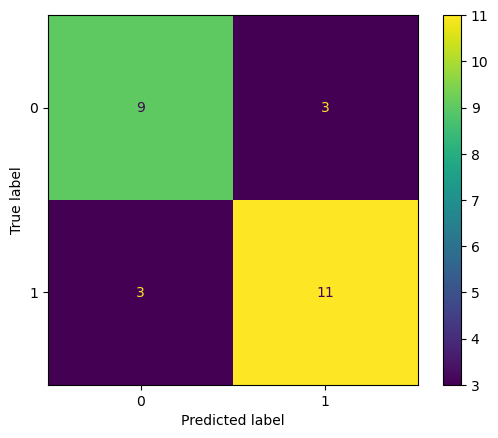

### Feature Importance

,Feature,Importance
0,X1,0.256
4,X5,0.211
2,X3,0.176
1,X2,0.136
5,X6,0.132
3,X4,0.089


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=random_state)

param_grid = {
    'n_estimators': [500],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [2, 3, 5],
    'max_features': [3, 4, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=random_state),
    param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)
rf_model = rf_grid.best_estimator_
y_pred = rf_model.predict(x_test)
    
display(Markdown('### RF Classifier Report'))

print('Best Parameters:')
print(rf_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)

### RF Classifier Report

Best Parameters:
{'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 500}
Testing Data Accuracy:
0.81
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.80      0.86      0.83        14

    accuracy                           0.81        26
   macro avg       0.81      0.80      0.81        26
weighted avg       0.81      0.81      0.81        26



### Confusion Matrix

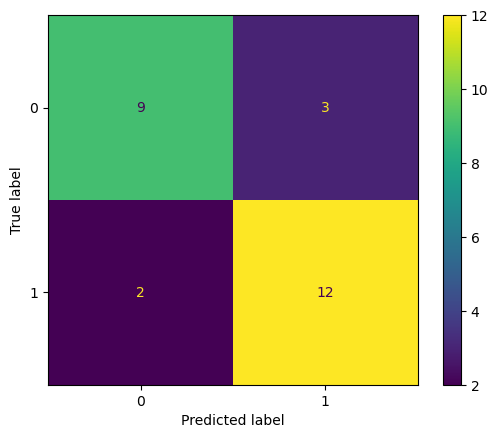

### Feature Importance

,Feature,Importance
1,X5,0.561
0,X1,0.439


In [6]:
x_drop = x.drop(columns=['X2', 'X3', 'X4', 'X6'])

x_train, x_test, y_train, y_test = train_test_split(x_drop, y, test_size=0.2, stratify=y, random_state=random_state)

param_grid = {
    'n_estimators': [500],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [2, 3, 5],
    'max_features': [3, 4, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=random_state),
    param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)
rf_model = rf_grid.best_estimator_
y_pred = rf_model.predict(x_test)
    
display(Markdown('### RF Classifier Report'))

print('Best Parameters:')
print(rf_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)